In [1]:
#Previsão de Score de Crédito de clientes

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from playhouse.sqlite_udf import median

warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
df = pd.read_excel('dados_credito.xlsx')

In [4]:
#EDA: analise exploratoria dos dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10476 entries, 0 to 10475
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CODIGO_CLIENTE              10476 non-null  int64  
 1   UF                          10476 non-null  object 
 2   IDADE                       10476 non-null  int64  
 3   ESCOLARIDADE                10476 non-null  object 
 4   ESTADO_CIVIL                10476 non-null  object 
 5   QT_FILHOS                   10476 non-null  int64  
 6   CASA_PROPRIA                10476 non-null  object 
 7   QT_IMOVEIS                  10476 non-null  int64  
 8   VL_IMOVEIS                  10476 non-null  int64  
 9   OUTRA_RENDA                 10476 non-null  object 
 10  OUTRA_RENDA_VALOR           10476 non-null  int64  
 11  TEMPO_ULTIMO_EMPREGO_MESES  10476 non-null  int64  
 12  TRABALHANDO_ATUALMENTE      10476 non-null  object 
 13  ULTIMO_SALARIO              104

In [15]:
#Ações necessárias:
#Alterar valor da variável ultimo_salario para numerico. Porém é preciso primeiro encontrar os dados no formato string, forçando a virar NAN,
#e já transformando os NAN para ZERO
df['ULTIMO_SALARIO'] = pd.to_numeric(df['ULTIMO_SALARIO'], errors='coerce').fillna(0)
df['ULTIMO_SALARIO']


0        1800.0
1        4800.0
2        2200.0
3        3900.0
4           0.0
          ...  
10471    4800.0
10472    2200.0
10473    3900.0
10474       0.0
10475    3100.0
Name: ULTIMO_SALARIO, Length: 10476, dtype: float64

In [20]:
#Ações necessárias:
#Substituir agora os valors nulos, pela mediana dos valores (nesse caso é melhor do que simplesmente excluir os valores)
mediana = df['ULTIMO_SALARIO'].median()
df['ULTIMO_SALARIO'] = df['ULTIMO_SALARIO'].replace(0.0, mediana)
df['ULTIMO_SALARIO']

0        1800.0
1        4800.0
2        2200.0
3        3900.0
4        6100.0
          ...  
10471    4800.0
10472    2200.0
10473    3900.0
10474    6100.0
10475    3100.0
Name: ULTIMO_SALARIO, Length: 10476, dtype: float64

In [22]:
#Confirmar que não existem mais valores nulos
df.isnull().sum()

CODIGO_CLIENTE                0
UF                            0
IDADE                         0
ESCOLARIDADE                  0
ESTADO_CIVIL                  0
QT_FILHOS                     0
CASA_PROPRIA                  0
QT_IMOVEIS                    0
VL_IMOVEIS                    0
OUTRA_RENDA                   0
OUTRA_RENDA_VALOR             0
TEMPO_ULTIMO_EMPREGO_MESES    0
TRABALHANDO_ATUALMENTE        0
ULTIMO_SALARIO                0
QT_CARROS                     0
VALOR_TABELA_CARROS           0
SCORE                         0
dtype: int64

In [24]:
#Confirmar o df.info para validar o campo Ultimo Salario
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10476 entries, 0 to 10475
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CODIGO_CLIENTE              10476 non-null  int64  
 1   UF                          10476 non-null  object 
 2   IDADE                       10476 non-null  int64  
 3   ESCOLARIDADE                10476 non-null  object 
 4   ESTADO_CIVIL                10476 non-null  object 
 5   QT_FILHOS                   10476 non-null  int64  
 6   CASA_PROPRIA                10476 non-null  object 
 7   QT_IMOVEIS                  10476 non-null  int64  
 8   VL_IMOVEIS                  10476 non-null  int64  
 9   OUTRA_RENDA                 10476 non-null  object 
 10  OUTRA_RENDA_VALOR           10476 non-null  int64  
 11  TEMPO_ULTIMO_EMPREGO_MESES  10476 non-null  int64  
 12  TRABALHANDO_ATUALMENTE      10476 non-null  object 
 13  ULTIMO_SALARIO              104

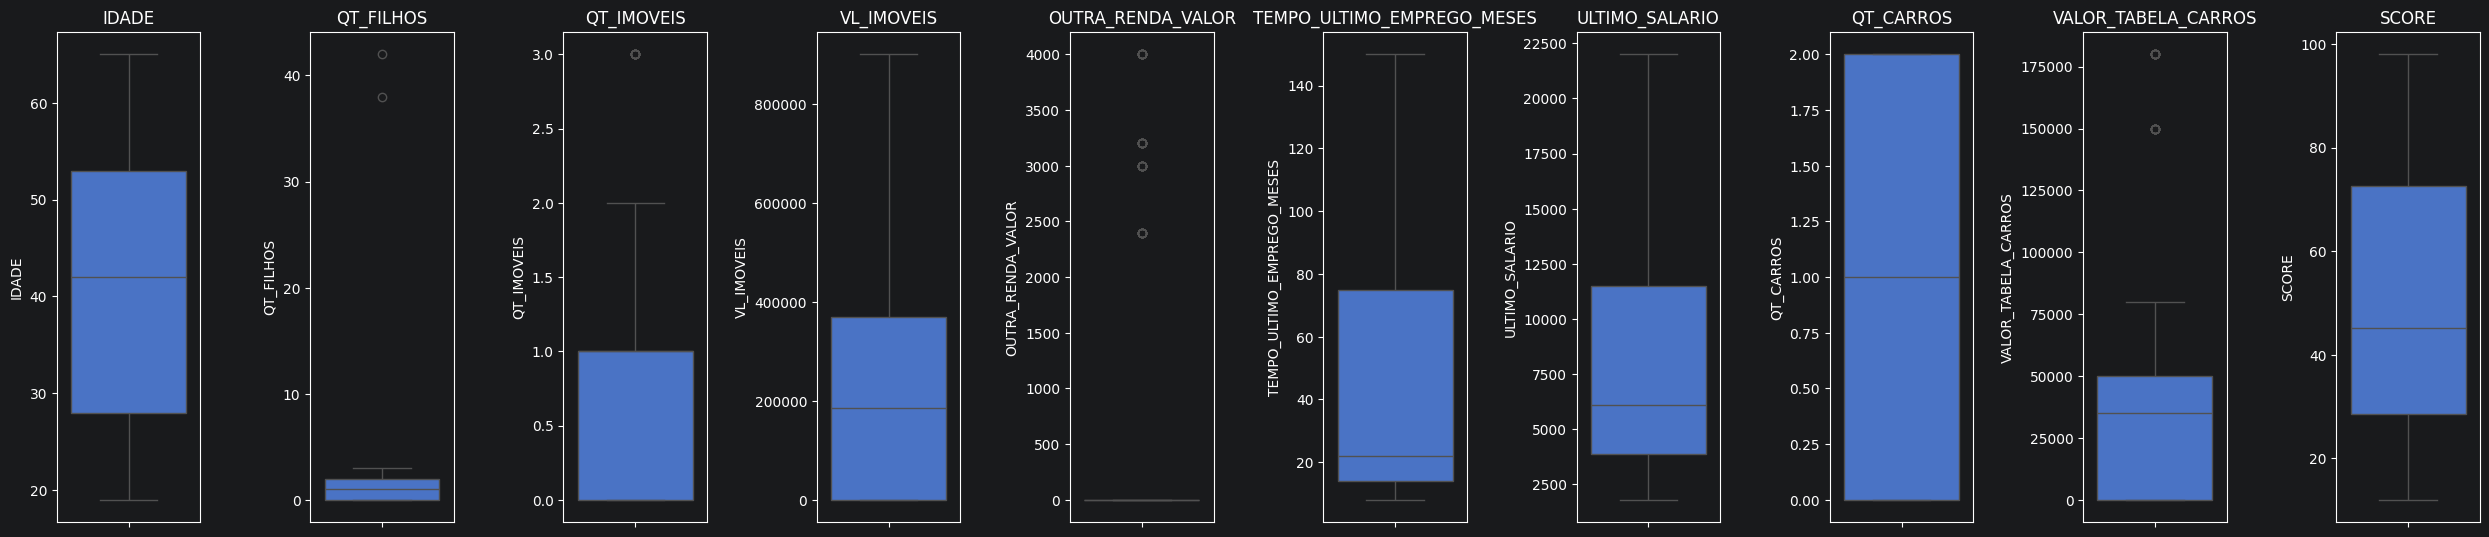

In [30]:
#Identificar outliers com boxplot, somente das vriáveis numéricas (nesse DF são 10)
colunas = ['IDADE', 'QT_FILHOS', 'QT_IMOVEIS', 'VL_IMOVEIS', 'OUTRA_RENDA_VALOR','TEMPO_ULTIMO_EMPREGO_MESES', 'ULTIMO_SALARIO', 'QT_CARROS', 'VALOR_TABELA_CARROS', 'SCORE']
#Como são escalas diferentes, o ideal é criar subplots para cada variável
fig, axes = plt.subplots(1, len(colunas), figsize=(25, 6))
for i, col in enumerate(colunas):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout(w_pad=2)
fig.subplots_adjust(top=0.85)
plt.show()


In [31]:
#Possíveis outliers nas variáveis: qt_filhos, qt_imoveis, valor_tabela_carros e outra_renda_valor

#Supondo quantidade de filhos maior do que 6 como outlier, teremos:
df.loc[df['QT_FILHOS'] >6]

,CODIGO_CLIENTE,UF,IDADE,ESCOLARIDADE,ESTADO_CIVIL,QT_FILHOS,CASA_PROPRIA,QT_IMOVEIS,VL_IMOVEIS,OUTRA_RENDA,OUTRA_RENDA_VALOR,TEMPO_ULTIMO_EMPREGO_MESES,TRABALHANDO_ATUALMENTE,ULTIMO_SALARIO,QT_CARROS,VALOR_TABELA_CARROS,SCORE
27,28,SP,48,Superior Completo,Divorciado,38,Sim,2,600000,Não,0,15,Sim,15000.0,1,70000,67.166667
10455,10456,SP,45,Segundo Grau Completo,Casado,42,Sim,1,220000,Não,0,18,Sim,2200.0,2,30000,23.000000


In [32]:
#Como só há 2 regisros podemos excluí-los:
df.drop(df.loc[df['QT_FILHOS'] >6].index, inplace=True)

In [35]:
#Para as outras variáveis da para identificar pelo agrupamento como estão distribuídas:
df.groupby(['QT_IMOVEIS']).size()


QT_IMOVEIS
0    4680
1    3761
2     989
3    1044
dtype: int64

In [36]:
#Para as outras variáveis da para identificar pelo agrupamento como estão distribuídas:
df.groupby(['VALOR_TABELA_CARROS']).size()

VALOR_TABELA_CARROS
0         3762
28000      468
30000      791
35000      792
40000      792
48000      522
50000     1314
70000      521
80000      522
150000     468
180000     522
dtype: int64

In [37]:
#Para as outras variáveis da para identificar pelo agrupamento como estão distribuídas:
df.groupby(['OUTRA_RENDA_VALOR']).size()

OUTRA_RENDA_VALOR
0       8350
2400     468
3000     612
3200     522
4000     522
dtype: int64

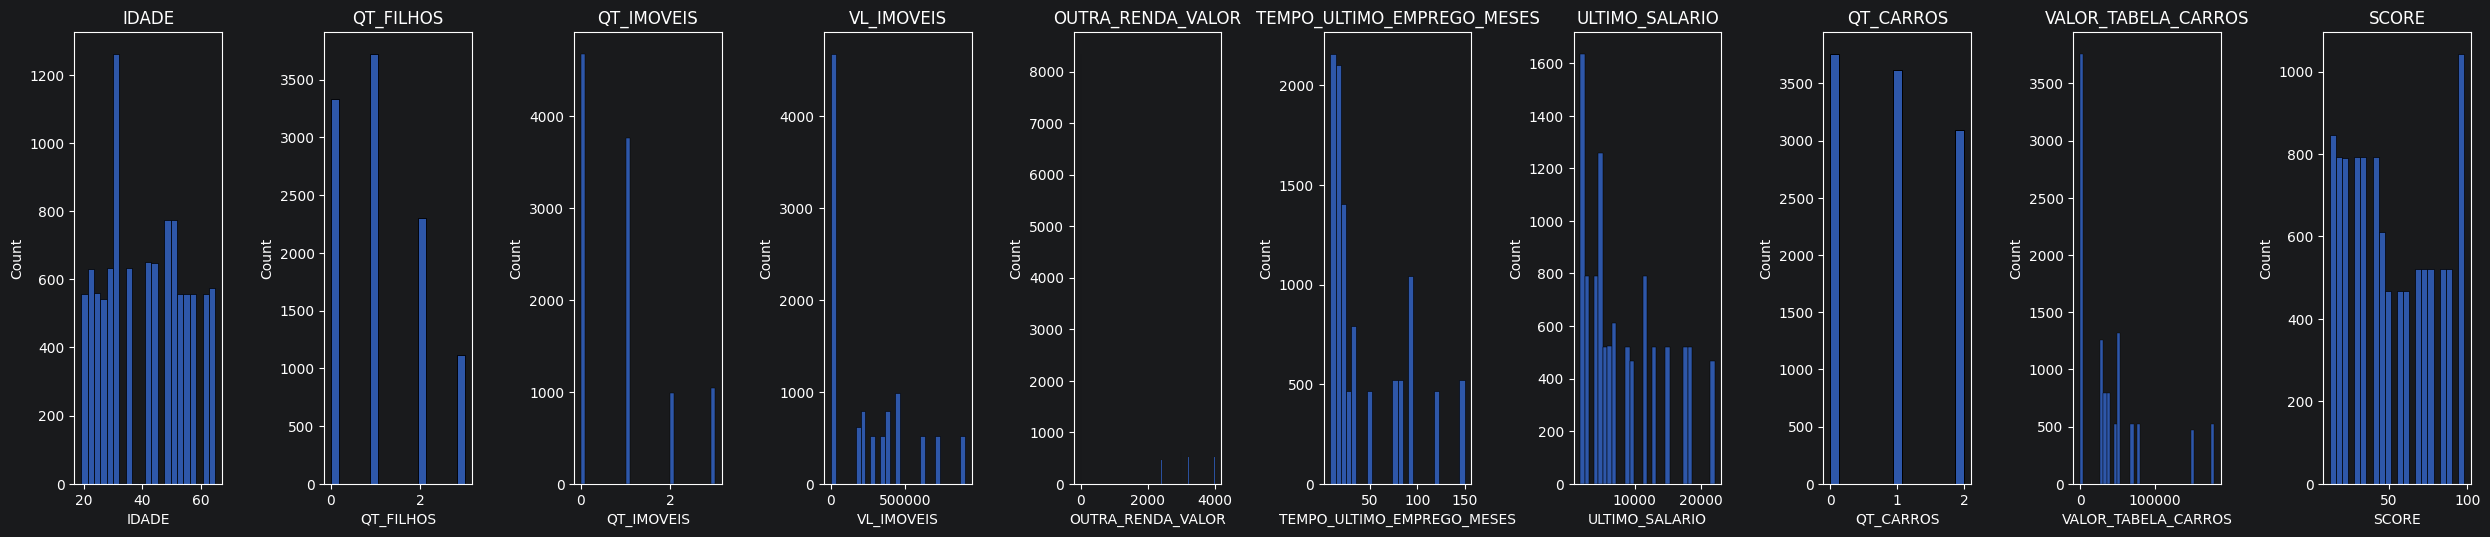

In [40]:
#Como as variáveis estão bem distribuídas, não são consideradas outliers.
#Entretanto os dados parecem não estarem distribuidos de forma normal

fig, axes = plt.subplots(1, len(colunas), figsize=(25, 6))
for i, col in enumerate(colunas):
    sns.histplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout(w_pad=2)
fig.subplots_adjust(top=0.85)
plt.show()

In [ ]:
#Sera necessário fazer um pré processamento para ficar mais próximo de uma distribuição normal